In [24]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.
from jaxopt import Bisection, Broyden, ScipyBoundedMinimize
import blackjax

import gpjax as gpx
from tensorflow_probability.substrates import jax as tfp
from tensorflow_probability.substrates.jax.mcmc import sample_halton_sequence

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

import sys
sys.path.append("..")
from src import GP, GPBanditSampler, HaltonSequence, MMD, Hellinger, MCMC


In [25]:
#===========================================
# G and K model
#===========================================

def quantile(u, theta):
    zu = jsp.stats.norm.ppf(u)
    c0 = 0.8
    c1 = 1.0 + c0 * jnp.tanh(0.5*theta[2]*zu)
    c2 = ( 1.0 + zu**2 )**theta[3]
    return theta[0] + theta[1] * zu * c1 * c2

root_finding = Bisection(optimality_fun=lambda u, x, theta: quantile(u, theta) - x, lower=0.0, upper=1.0, check_bracket=False)
inv_quantile = lambda x, theta: root_finding.run(x=x, theta=theta).params
jac_quantile = jax.jacrev(quantile, argnums=0)

inv_quantile_vmap = jax.vmap(inv_quantile, in_axes=(0,None))
jac_quantile_vmap = jax.vmap(jac_quantile, in_axes=(0,None))

def logpdf_vmap(X, theta):
    inv_Q = inv_quantile_vmap(X, theta)
    jac_Q = jac_quantile_vmap(inv_Q, theta)
    log_Q = - jnp.log( jac_Q )
    return jnp.nan_to_num(log_Q, nan=-1000, posinf=1000, neginf=-1000)


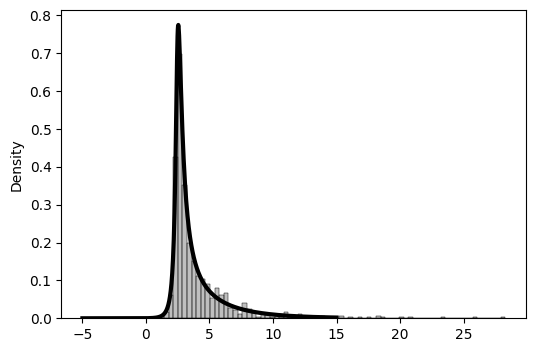

In [26]:
#===========================================
# Load Data
#===========================================

a = 3.0
b = 1.0
g = 2.0
k = 0.5
theta_0 = jnp.array([a, b, g, k])

data = jnp.load('Data/data_1000.npy')

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plt_x = jnp.linspace(-5, 15, 1000)
sns.lineplot(x=plt_x, y=jnp.exp(logpdf_vmap(plt_x, theta_0)), color="black", linewidth=3, ax=ax)
sns.histplot(x=data, stat="density", alpha=0.5, color="gray", ax=ax)
plt.show()


In [27]:
#===========================================
# Posterior
#===========================================

@jax.jit
def loglikelihood(theta):
    return jnp.sum( logpdf_vmap(data, theta) )

@jax.jit
def logprior(theta):
    return - 4 * jnp.log( 10 )

@jax.jit
def logposterior(theta):
    return loglikelihood(theta) + logprior(theta)


In [28]:
#===========================================
# Excute
#===========================================

key = jrandom.key(0)
key, _key = jax.random.split(key)
bounds = ( jnp.array([0.0, 0.0, 0.0, 0.0]), jnp.array([10.0, 10.0, 10.0, 10.0]) )
halton = HaltonSequence(dim=4, bounds=bounds, rngkey=_key)

X = halton.generate(jnp.arange(320000))
y = jnp.array([ logposterior(x) for x in X ])
w = jnp.exp( y - jsp.special.logsumexp( y ) )


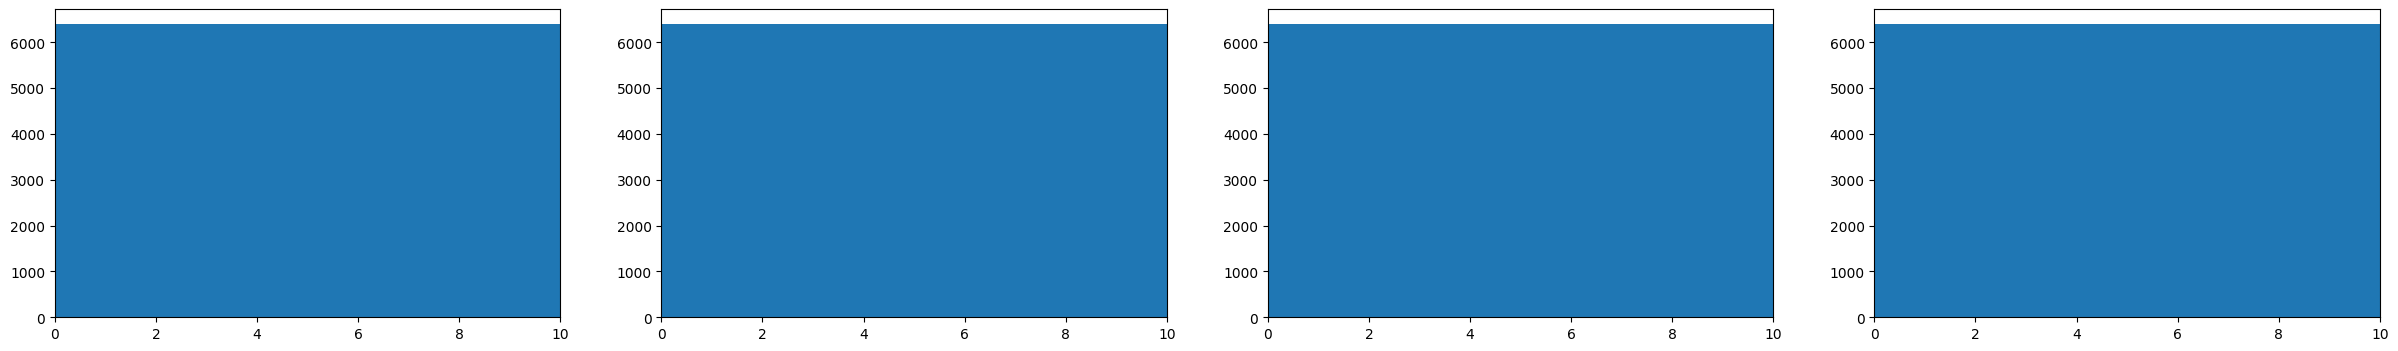

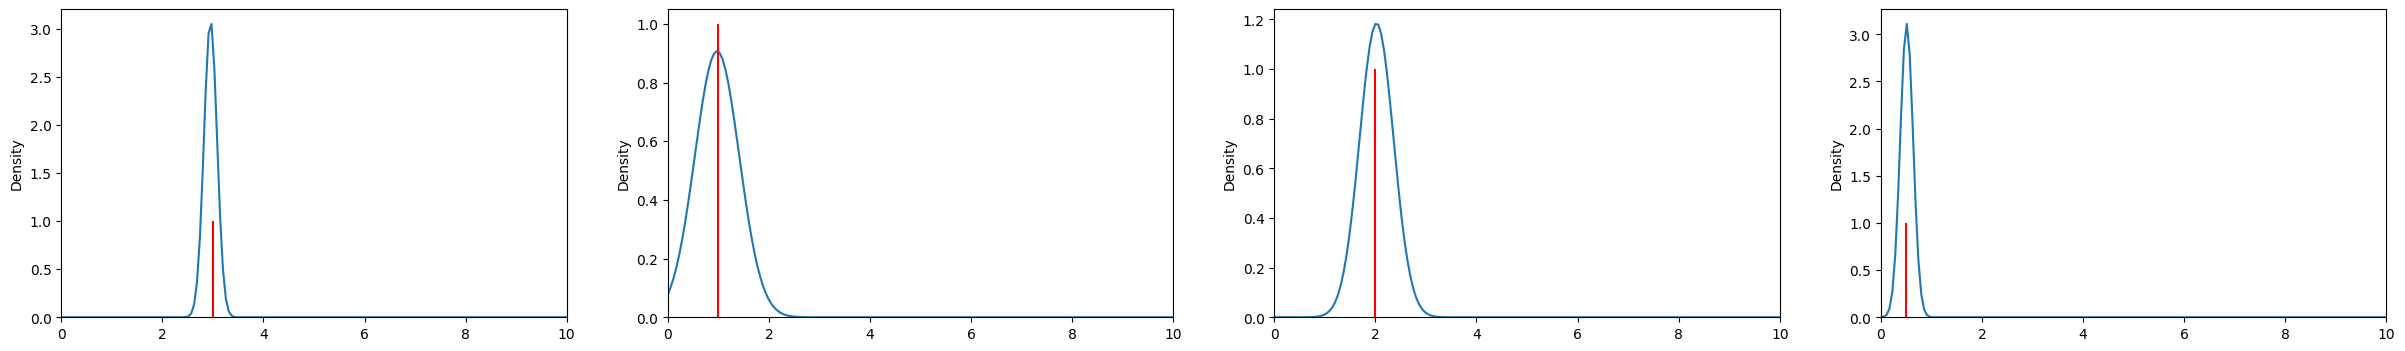

In [31]:
#===========================================
# Plot
#===========================================

fig, axs = plt.subplots(1, 4, figsize=(30, 4))
for i in range(4):
    axs[i].hist(X[:,i], bins=50)
    axs[i].set_xlim(0, 10)

fig, axs = plt.subplots(1, 4, figsize=(30, 4))
for i in range(4):
    sns.kdeplot(x=X[:,i], weights=w, ax=axs[i])
    axs[i].vlines(theta_0[i], 0, 1, color="red")
    axs[i].set_xlim(0, 10)

with open('Data/samples.npy', 'wb') as f:
    jnp.save(f, X)

with open('Data/logvals.npy', 'wb') as f:
    jnp.save(f, y)

with open('Data/weights.npy', 'wb') as f:
    jnp.save(f, w)
